In [1]:
!pip install --upgrade transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 105.0 MB/s eta 0:00:00


In [2]:
"""Scoring logic for the structured output task.

Provides parsers for each format, field matching, and scoring functions.
"""

import csv
import io
import json
import xml.etree.ElementTree as ET
from collections import defaultdict


# ---------------------------------------------------------------------------
# Format parsers — each returns a dict or None on failure
# ---------------------------------------------------------------------------

def parse_json(text: str) -> dict | None:
    """Try to parse text as JSON. Return dict or None."""
    try:
        result = json.loads(text.strip())
        if isinstance(result, dict):
            return result
        return None
    except (json.JSONDecodeError, ValueError):
        return None


def parse_yaml(text: str) -> dict | None:
    """Try to parse text as YAML. Return dict or None."""
    try:
        import yaml
        result = yaml.safe_load(text.strip())
        if isinstance(result, dict):
            return result
        return None
    except Exception:
        return None


def parse_xml(text: str) -> dict | None:
    """Parse XML, extract child elements of <record> as dict."""
    try:
        text = text.strip()
        root = ET.fromstring(text)
        result = {}
        for child in root:
            result[child.tag] = child.text if child.text else ""
        if result:
            return result
        return None
    except ET.ParseError:
        return None


def parse_csv(text: str) -> dict | None:
    """Parse CSV (header + data row) into dict."""
    try:
        text = text.strip()
        reader = csv.DictReader(io.StringIO(text))
        rows = list(reader)
        if len(rows) >= 1:
            return dict(rows[0])
        return None
    except Exception:
        return None


def parse_toml(text: str) -> dict | None:
    """Try to parse text as TOML. Return dict or None."""
    try:
        # Python 3.11+ has tomllib in stdlib
        try:
            import tomllib
        except ImportError:
            import tomli as tomllib
        result = tomllib.loads(text.strip())
        if isinstance(result, dict):
            return result
        return None
    except Exception:
        return None


PARSERS = {
    "json": parse_json,
    "yaml": parse_yaml,
    "xml": parse_xml,
    "csv": parse_csv,
    "toml": parse_toml,
}


# ---------------------------------------------------------------------------
# Field matching
# ---------------------------------------------------------------------------

def _normalize_value(val) -> str:
    """Normalize a value to string for comparison."""
    if val is None:
        return ""
    return str(val).strip().lower()


def _values_match(predicted, expected) -> bool:
    """Check if predicted value matches expected value."""
    # Try numeric comparison first
    try:
        pred_num = float(str(predicted))
        exp_num = float(str(expected))
        # For integers, exact match
        if isinstance(expected, int):
            return int(pred_num) == exp_num
        # For floats, tolerance of 0.01
        return abs(pred_num - exp_num) < 0.01
    except (ValueError, TypeError):
        pass

    # Fall back to case-insensitive string comparison
    return _normalize_value(predicted) == _normalize_value(expected)


def match_fields(predicted: dict | None, ground_truth: dict) -> float:
    """Return fraction of ground truth fields correctly matched in predicted.

    Args:
        predicted: Parsed output dict, or None if parsing failed.
        ground_truth: Expected field values.

    Returns:
        Float between 0.0 and 1.0.
    """
    if predicted is None or not ground_truth:
        return 0.0

    correct = 0
    total = len(ground_truth)

    for key, expected_val in ground_truth.items():
        if key in predicted and _values_match(predicted[key], expected_val):
            correct += 1

    return correct / total


# ---------------------------------------------------------------------------
# Per-sample and aggregate scoring
# ---------------------------------------------------------------------------

def score_sample(predicted_text: str, ground_truth: dict, format_name: str) -> dict:
    """Score a single prediction.

    Args:
        predicted_text: The model's raw output string.
        ground_truth: Dict of expected field values.
        format_name: The target format ("json", "yaml", etc.).

    Returns:
        Dict with "valid" (0/1), "field_accuracy" (float), "score" (float).
    """
    parser = PARSERS.get(format_name)
    if parser is None:
        return {"valid": 0, "field_accuracy": 0.0, "score": 0.0}

    parsed = parser(predicted_text)
    valid = 1 if parsed is not None else 0
    field_accuracy = match_fields(parsed, ground_truth)
    score = 0.5 * valid + 0.5 * field_accuracy

    return {
        "valid": valid,
        "field_accuracy": field_accuracy,
        "score": score,
    }


def score_all(predictions: list[dict], ground_truths: list[dict]) -> dict:
    """Score all predictions against ground truths.

    Args:
        predictions: List of dicts with "prediction" and "format" keys.
        ground_truths: List of dicts with "fields" and "format" keys.

    Returns:
        Dict with "overall" score, "per_format" breakdown, and "details".
    """
    assert len(predictions) == len(ground_truths), (
        f"Prediction count ({len(predictions)}) != ground truth count ({len(ground_truths)})"
    )

    details = []
    format_scores = defaultdict(list)

    for pred, gt in zip(predictions, ground_truths):
        fmt = gt["format"]
        result = score_sample(pred["prediction"], gt["fields"], fmt)
        result["format"] = fmt
        details.append(result)
        format_scores[fmt].append(result["score"])

    per_format = {}
    for fmt, scores in sorted(format_scores.items()):
        per_format[fmt] = round(sum(scores) / len(scores), 4)

    all_scores = [d["score"] for d in details]
    overall = round(sum(all_scores) / len(all_scores), 4) if all_scores else 0.0
    valid_count = sum(d["valid"] for d in details)

    return {
        "overall": overall,
        "per_format": per_format,
        "total_samples": len(details),
        "valid_count": valid_count,
        "valid_ratio": round(valid_count / len(details), 4) if details else 0.0,
        "details": details,
    }

In [3]:
"""Baseline LoRA fine-tuning script for the structured output task.

This trains a LoRA adapter on top of Qwen 3.5-0.8B using the generated
training data. The baseline is intentionally simple — there is plenty of
room for improvement (more LoRA targets, more epochs, better prompts, etc.).

Usage:
    python -m train.baseline_train [--output_dir OUTPUT_DIR]
"""

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import json
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
from datasets import Dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
)

from sklearn.model_selection import train_test_split

MODEL_NAME = "Qwen/Qwen3.5-0.8B"
LORA_R = 64
LORA_ALPHA = 128
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
TRAIN_EPOCHS = 1
TRAIN_BATCH_SIZE = 4
TRAIN_GRAD_ACCUM = 4
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.05

# Inference
MAX_NEW_TOKENS = 64

# System prompt used in chat template
SYSTEM_PROMPT = (
    "You convert natural language into structured data.\n"
    "STRICT RULES:\n"
    "- Output ONLY valid {format}\n"
    "- No explanations\n"
    "- No extra text\n"
)

STOP_STRINGS = {
    "json": ["}", "<|user|>", "<|assistant|>"],
    "xml": ["</record>", "<|user|>", "<|assistant|>"],
    "yaml": ["\n<|", "<|user|>", "<|assistant|>"],
    "csv": ["\n<|", "<|user|>", "<|assistant|>"],
    "toml": ["\n<|", "<|user|>", "<|assistant|>"],
}

def apply_stop(text, format_name):
    stops = STOP_STRINGS.get(format_name, [])
    for s in stops:
        idx = text.find(s)
        if idx != -1:
            return text[: idx + len(s)]
    return text


def load_data(data_path: str, seed: int = 42) -> list[dict]:
    """Load training samples from JSONL file."""
    samples = []
    with open(data_path, encoding="utf-8") as f:
        for line in f:
            samples.append(json.loads(line))
    random.seed(seed)
    random.shuffle(samples)
    return samples


def format_chat_messages(sample: dict, tokenizer) -> list[dict]:
    system_prompt = SYSTEM_PROMPT.format(format=sample["format"].upper())

    return [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": sample["input"]},
        {
            "role": "assistant",
            "content": sample["output"] + tokenizer.eos_token,  # 🔥 CRITICAL
        },
    ]


def tokenize_sample(messages: list[dict], tokenizer) -> dict:
    """Tokenize a chat message list, masking input tokens in labels."""
    # Full conversation (with assistant response)
    full_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False,
    )
    full_ids = tokenizer(full_text, return_tensors="pt", truncation=True, max_length=1024)

    # Conversation up to assistant response (for masking)
    prompt_messages = messages[:-1]
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True,
    )
    prompt_ids = tokenizer(prompt_text, return_tensors="pt", truncation=True, max_length=1024)

    input_ids = full_ids["input_ids"][0]
    labels = input_ids.clone()
    # Mask prompt tokens so we only compute loss on the assistant response
    prompt_len = prompt_ids["input_ids"].shape[1]
    labels[:prompt_len] = -100

    return {
        "input_ids": input_ids,
        "attention_mask": full_ids["attention_mask"][0],
        "labels": labels,
    }

def tokenize_dataset(data, tokenizer):
    tokenized = []
    for sample in data:
        messages = format_chat_messages(sample, tokenizer)
        tok = tokenize_sample(messages, tokenizer)
        tokenized.append({
            "input_ids": tok["input_ids"].tolist(),
            "attention_mask": tok["attention_mask"].tolist(),
            "labels": tok["labels"].tolist()
        })
    return Dataset.from_list(tokenized)

def generate_text(model, tokenizer, prompt, format_name):
    system_prompt = SYSTEM_PROMPT.format(format=format_name.upper())

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt},
    ]

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,  # 🔥 ADD THIS
            use_cache=True,
            stopping_criteria=stopping_criteria,
        )

    generated = output_ids[0][inputs["input_ids"].shape[1]:]

    response = tokenizer.decode(generated, skip_special_tokens=True)
    response = apply_stop(response, format_name)

    for bad in ["user", "assistant"]:
        idx = response.find(bad)
        if idx != -1:
            response = response[:idx]

    # 🔥 CRITICAL: free memory
    del inputs, output_ids, generated
    torch.cuda.empty_cache()

    return response.strip()

def pipeline(train_data_path, valid_data_path, output_dir, max_steps):
    def build_compute_metrics(model, tokenizer, val_data):
        def compute_metrics(eval_pred):
            model.eval()
    
            scores = []
            valid = 0
    
            for sample in val_data[:]:
                pred = generate_text(
                    model,
                    tokenizer,
                    sample["input"],
                    sample["format"],
                )
    
                result = score_sample(
                    pred,
                    sample["fields"],
                    sample["format"],
                )
    
                scores.append(result["score"])
                valid += result["valid"]
    
            return {
                "eval_score": sum(scores) / len(scores),
                "valid_ratio": valid / len(scores),
            }
    
        return compute_metrics
    
    print(f"Loading model: {MODEL_NAME}")
    # 4-bit quantization to fit on consumer GPUs
    # bnb_config = BitsAndBytesConfig(
    #     load_in_4bit=True,
    #     bnb_4bit_quant_type="nf4",
    #     bnb_4bit_use_double_quant=True,
    #     bnb_4bit_compute_dtype=torch.bfloat16,
    # )

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        # quantization_config=bnb_config,
        device_map='auto',
        trust_remote_code=True,
    )

    # Apply LoRA — baseline uses only q_proj and v_proj
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES,
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    # Load and tokenize data
    print(f"Loading data from: {train_data_path} and {valid_data_path}")
    train_data, val_data = load_data(train_data_path), load_data(valid_data_path)
    print(f"  {len(train_data)} + {len(val_data)} = {len(train_data) + len(val_data)} samples loaded")
    print(f"Train: {len(train_data)}, Val: {len(val_data)}")

    train_dataset = tokenize_dataset(train_data, tokenizer)
    val_dataset = tokenize_dataset(val_data, tokenizer)

    # Training arguments — baseline settings
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=TRAIN_EPOCHS if max_steps <= 0 else 1,
        max_steps=max_steps if max_steps > 0 else -1,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=TRAIN_GRAD_ACCUM,
        learning_rate=LEARNING_RATE,
        warmup_ratio=WARMUP_RATIO,
        bf16=torch.cuda.is_bf16_supported(),
        fp16=not torch.cuda.is_bf16_supported(),
        
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="best",

        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        
        logging_steps=50,
        save_total_limit=2,
        remove_unused_columns=False,
        report_to="none",
    )

    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        padding=True,
        return_tensors="pt",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        # compute_metrics=build_compute_metrics(model, tokenizer, val_data)
    )

    print("Starting training...")
    trainer.train()

    logs = trainer.state.log_history

    train_steps = []
    train_losses = []
    
    eval_steps = []
    eval_losses = []
    
    for log in logs:
        if "loss" in log and "eval_loss" not in log:
            train_steps.append(log["step"])
            train_losses.append(log["loss"])
    
        if "eval_loss" in log:
            eval_steps.append(log["step"])
            eval_losses.append(log["eval_loss"])

    import matplotlib.pyplot as plt

    plt.figure()
    
    plt.plot(train_steps, train_losses, label="train_loss")
    plt.plot(eval_steps, eval_losses, label="eval_loss")
    
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.show()

    # Save the LoRA adapter
    print(f"Saving adapter to: {output_dir}")
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    print("Done!")

Loading model: Qwen/Qwen3.5-0.8B


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

trainable params: 25,559,040 || all params: 777,952,064 || trainable%: 3.2854
Loading data from: /kaggle/input/datasets/abukanabek/hometask-2026-data/train.jsonl and /kaggle/input/datasets/abukanabek/hometask-2026-data/valid.jsonl
  69750 + 1000 = 70750 samples loaded
Train: 69750, Val: 1000


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training...


Step,Training Loss,Validation Loss
100,0.005916,0.005708
200,0.004774,0.005042
300,0.003457,0.005445
400,0.045319,0.009678
500,0.011705,0.009413
600,0.003164,0.003571
700,0.003256,0.001761
800,0.001362,0.002352
900,0.001092,0.001310
1000,0.007649,0.002634


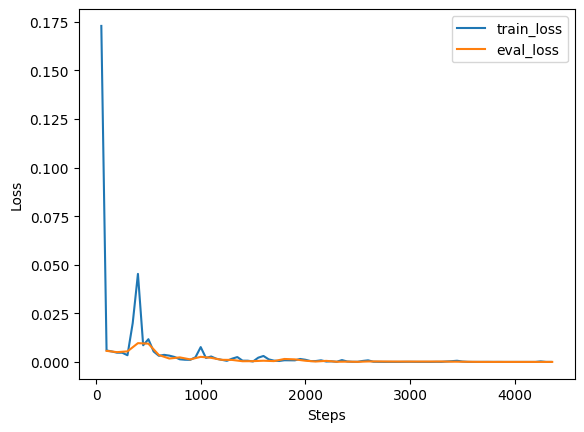

Saving adapter to: result
Done!


In [4]:
train_data_path = '/kaggle/input/datasets/abukanabek/hometask-2026-data/train.jsonl'
valid_data_path = '/kaggle/input/datasets/abukanabek/hometask-2026-data/valid.jsonl'
output_dir = 'result'
max_steps = -1

pipeline(train_data_path, valid_data_path, output_dir, max_steps)

In [5]:
adapter_config_json = "/kaggle/working/result/adapter_config.json"
adapter_model_safetensors = "/kaggle/working/result/adapter_model.safetensors"

size_mb = (os.path.getsize(adapter_config_json) + os.path.getsize(adapter_model_safetensors)) / (1024 ** 2)
print(f'{size_mb:.2f} MB')

97.53 MB
